# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
import requests
import zipfile
import io
import os
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

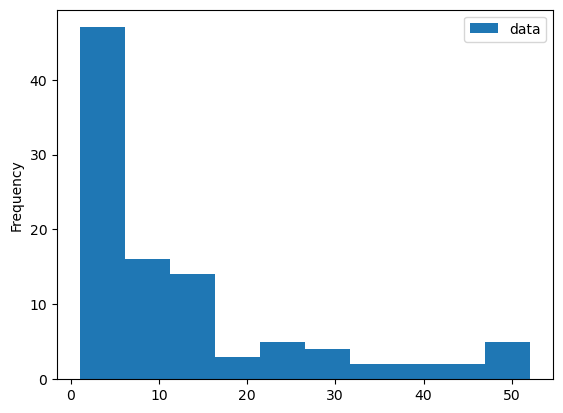

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

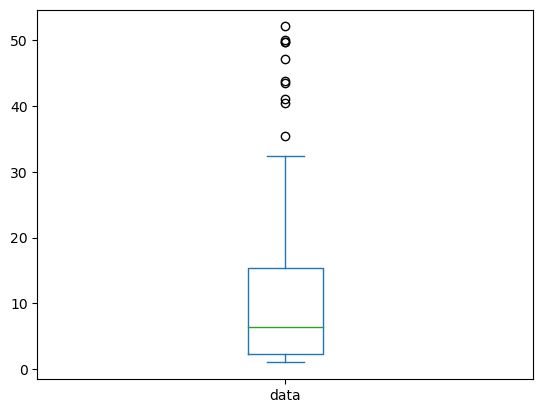

In [3]:
df.plot.box()

<span style="color:green">

- Histogram
    - pro: 
        - Can see distribution shape of the drugs by price. 
        - Can easily see the (right) skew of the data.
        - Can see range of the price of drugs and the range of frequency of number of drugs sold. 
        - We can easily tell that the pharmacy has sold more lower priced drugs than higher priced drugs. 
    - con:
        - Can't easily tell what the quartiles are. 
        - Cant tell the names of the individual drugs. 
        - Can't tell exactly how much the more expensive drugs cost as it it appears the prices are binned. 
- Boxplot
    - pro:
        - Can easily tell what the quartiles are, which helps judge how much more expensive the most expenive drugs (the outliers pts int he boxplot) are.
        - Can easily tell which pts are outliers or the most expensive drugs. 
    - con:
        - We don't have the names for the drugs so we can't name the most expenive drugs.
        - Can't tell the actual density of the distribution (how many drugs sold for xx price), only the quartiles and outliers. 

- Which would I choose: I would pick the boxplot becuse I can guess how much the higher end outliers cost, which would eb the more expensive drugs. I can also guestimate the median and guess how much more expensive the outliears are compaired to the regular drugs. 
- How would I modify the formatting:
    - Histogram:
        - I would add a descriptive title. 
        - Label the X axis 'prices'.
    - Boxplot:
        - I would add a descriptive title. 
        - label the y axis "prices" and label the x axis "drugs".
</span>

# 3. Homework - working on your chosen project datasets this semester

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

<span style="color:green">

- From the CICAndMal2017 Dataset collected by the Canadian Institute for Cybersecurity, I am going to look at the different types of malware (and benign) applications that were found in the android store in 2015, 2016, and 2017. 
- There are 4 different catagories of malware and 42 unique malware families across those catagories with a varying number of camptured samples for each family. 
- There were 3 different states of data collecting (instalation - data collected 1 to 3 min after installing the application, before restart - data collected 15 min before a restart, after restart - data collected 15 min after a restart).
- The collected network traffic was stored in .pcap files and the features were then extracted using CICFlowMeter-V3 and placed into csv files, which is what I am utilizing for this project.
- The dataframe 'data' is a master dataframe of all the applications, which have two new columns, 'Category' and 'Family', to help distinguish the applications. I commented out the code used to create 'data' for ease of reading. 
</span>

In [4]:
data = pd.read_csv("df.csv")
data.columns = data.columns.str.strip()
data2= data

/var/folders/db/yvyz2b5s7m5bjk2hycfnf2d40000gn/T/ipykernel_58541/45097139.py:1: DtypeWarning: Columns (25,47,55,57,62) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("df.csv")


In [5]:
df_balanced = data.groupby('Category', group_keys=False).apply(lambda x: x.sample(n=min(data['Category'].value_counts()), random_state = 42)).reset_index(drop=True)
print(df_balanced['Category'].value_counts())

Category
Adware        237133
Benign        237133
Ransomware    237133
SMSmalware    237133
Scareware     237133
Name: count, dtype: int64


/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 92.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 92.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 93.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 91.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/anushreeyagurung/

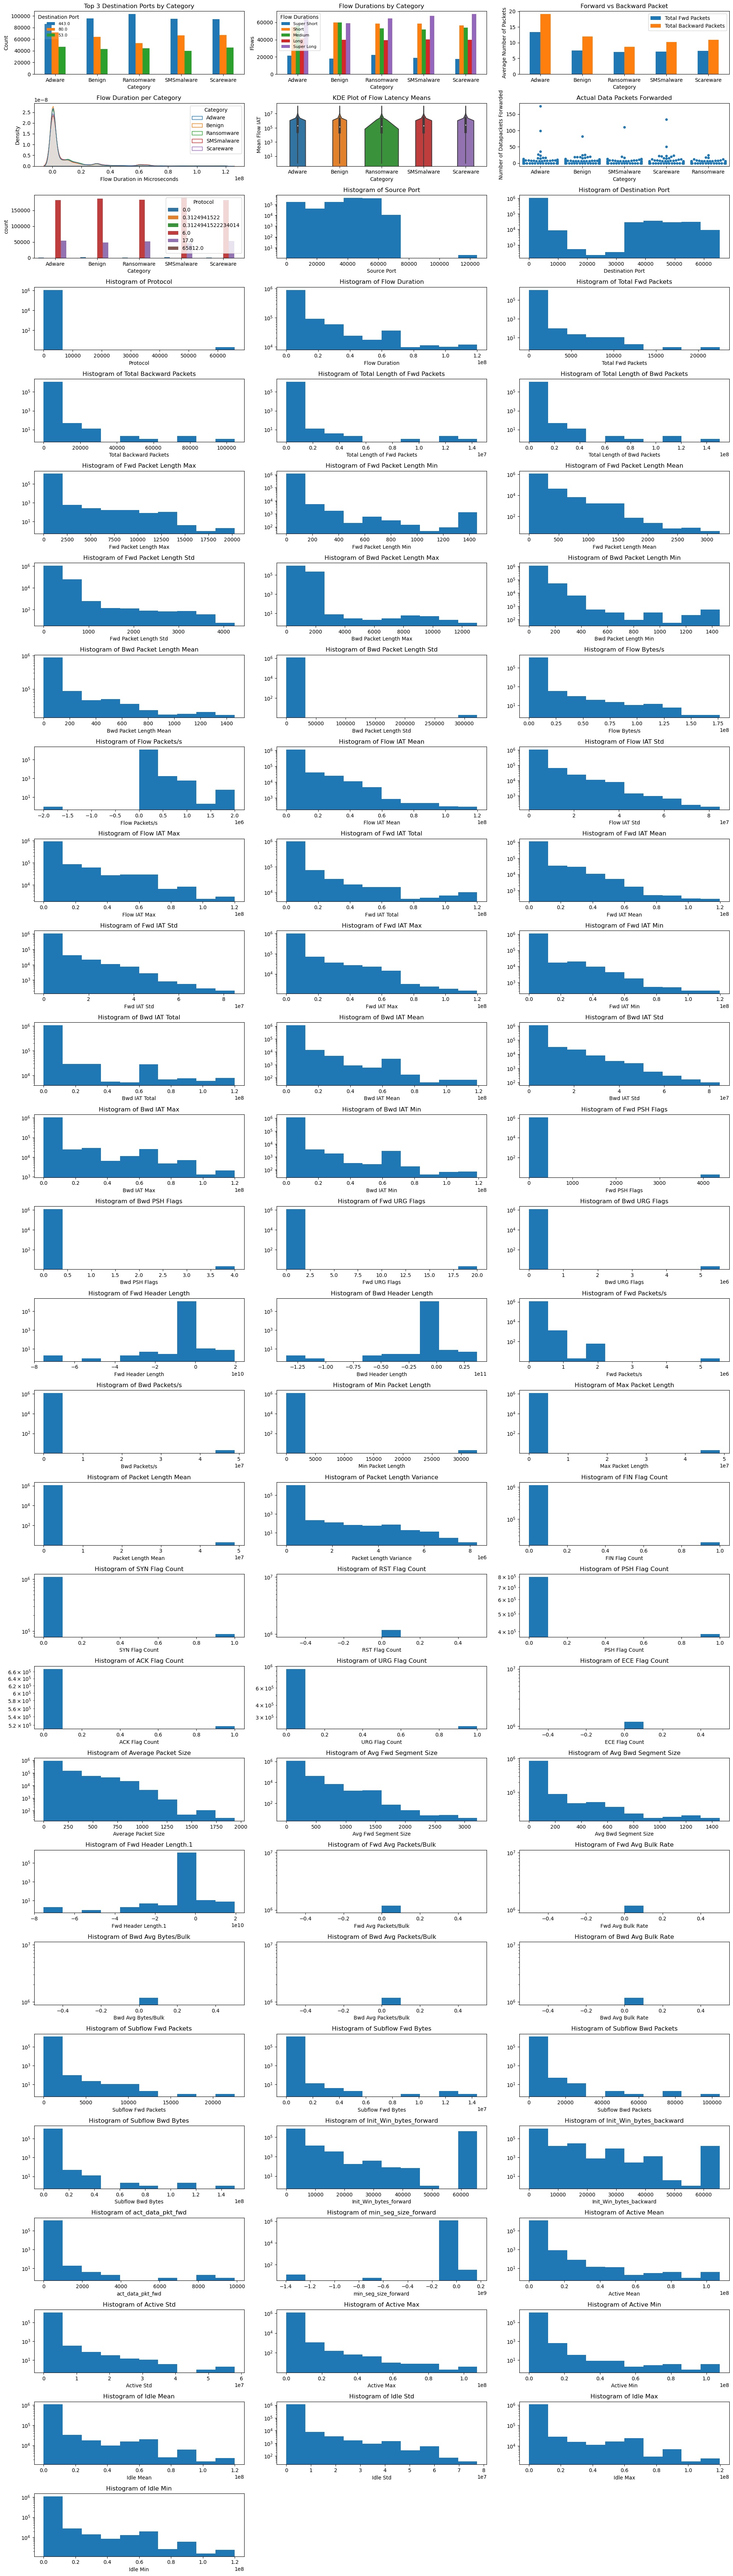

In [13]:
fig, ax = plt.subplots(28, 3, figsize = (20, 70))

top_ports = df_balanced.groupby('Category')['Destination Port'].apply(lambda x: x.value_counts().head(3)).unstack()
top_ports.plot(kind = 'bar', rot=0, ax=ax[0,0])
ax[0, 0].set_title("Top 3 Destination Ports by Category")
ax[0, 0].set_xlabel("Category")
ax[0, 0].set_ylabel("Count")
ax[0, 0].legend(title = 'Destination Port', loc="upper left", fontsize=8, framealpha = .1)

df_balanced['Duration_bin'] = pd.cut(df_balanced['Flow Duration'], bins = [0, 1000, 100000, 1000000, 10000000, 10000000000000000000000], labels = ['Super Short', 'Short', 'Medium', 'Long', 'Super Long'])
counts = df_balanced.groupby(['Category', 'Duration_bin']).size().unstack()
counts.plot(kind='bar', rot = 0, ax = ax[0, 1])
ax[0, 1].set_title("Flow Durations by Category")
ax[0, 1].set_xlabel("Category")
ax[0, 1].set_ylabel("Flows")
ax[0, 1].legend(title = 'Flow Durations', loc="upper left", fontsize=8)

df_balanced.groupby('Category')[['Total Fwd Packets', 'Total Backward Packets']].mean().plot(kind = 'bar', rot = 0, ax=ax[0, 2])
ax[0, 2].set_ylabel("Average Number of Packets")
ax[0, 2].set_xlabel("Category")
ax[0, 2].set_title("Forward vs Backward Packet")

sns.kdeplot(data=df_balanced, x= 'Flow Duration', hue = 'Category', fill=True, alpha=.05, ax=ax[1, 0])
ax[1, 0].set_xlabel("Flow Duration in Microseconds")
ax[1, 0].set_title('Flow Duration per Category')
sns.move_legend(ax[1,0], loc="upper right")

sns.violinplot(data=df_balanced, x='Category', y='Flow IAT Mean', ax=ax[1,1])
ax[1, 1].set_xlabel("Category")
ax[1, 1].set_ylabel("Mean Flow IAT")
ax[1, 1].set_title('KDE Plot of Flow Latency Means')
ax[1, 1].set_yscale('log')

sns.swarmplot(data=df_balanced.sample(2000), x='Category', y='act_data_pkt_fwd', size = 5, ax=ax[1, 2])
ax[1, 2].set_xlabel('Category')
ax[1, 2].set_ylabel('Number of Datapackets Forwarded')
ax[1, 2].set_title("Actual Data Packets Forwarded")

sns.countplot(data = df_balanced, x = 'Category', hue = 'Protocol', ax=ax[2, 0])

i = 2
j = 1

for x in df_balanced.select_dtypes(include='number'):
    ax[i, j].hist(df_balanced[x])
    ax[i, j].set_title("Histogram of "+x)
    ax[i, j].set_xlabel(x)
    # if df_balanced[x].max() > 10000: 
    #     ax[i, j].set_xscale('log')
    if np.histogram(df_balanced[x].dropna(), bins = 100)[0].max() > 10000: 
        ax[i, j].set_yscale('log')
    j += 1
    if j == 3:
        j = 0
        i +=1

for x in range(i, 28):
    for y in range(3):
        if x > i or y >= j:     
            ax[x, y].axis('off')

plt.tight_layout()
plt.show()

In [7]:
df_balanced.describe()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.185665e+06,1.185665e+06,1.185665e+06,1.185665e+06,1.185665e+06,1.185665e+06,1.185665e+06,1.185665e+06,1.185665e+06,1.185665e+06,...,1.185657e+06,1.185657e+06,1.185657e+06,1.185656e+06,1.185656e+06,1.185656e+06,1.185656e+06,1.185656e+06,1.185656e+06,1.185656e+06
mean,3.899913e+04,5.567382e+03,8.434955e+00,1.120035e+07,8.533041e+00,1.217268e+01,8.804867e+02,1.347737e+04,2.198458e+02,1.270122e+01,...,1.711770e+00,-1.383317e+04,1.660439e+05,2.346782e+04,1.896427e+05,1.472857e+05,4.331494e+06,3.478920e+05,4.635202e+06,4.063605e+06
std,1.825539e+04,1.486074e+04,8.558600e+01,2.239930e+07,7.460375e+01,2.295872e+02,2.772466e+04,3.300875e+05,4.267828e+02,5.974561e+01,...,2.035135e+01,4.769251e+06,9.523158e+05,3.473402e+05,1.137137e+06,8.881479e+05,1.492089e+07,3.003381e+06,1.567427e+07,1.456612e+07
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-1.395063e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.437700e+04,8.000000e+01,6.000000e+00,4.812600e+04,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.346800e+04,4.430000e+02,6.000000e+00,5.312440e+05,2.000000e+00,1.000000e+00,3.100000e+01,3.100000e+01,3.100000e+01,0.000000e+00,...,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,5.248500e+04,4.430000e+02,6.000000e+00,1.073570e+07,5.000000e+00,4.000000e+00,4.390000e+02,3.490000e+02,3.340000e+02,2.100000e+01,...,1.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.245600e+05,6.548700e+04,6.581200e+04,1.200000e+08,2.254300e+04,1.043090e+05,1.438552e+07,1.503985e+08,2.027200e+04,1.460000e+03,...,9.875000e+03,1.705249e+08,1.074960e+08,5.795123e+07,1.074960e+08,1.074960e+08,1.198804e+08,7.737303e+07,1.198804e+08,1.198804e+08


In [8]:
df_balanced.mode()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Family,Category,Duration_bin
0,8.0.6.4-8.6.0.1-0-0-0,10.42.0.211,443.0,10.42.0.1,443.0,6.0,30/06/2017 03:15:38,28.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Benign2016,Adware,Super Long
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Benign,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ransomware,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SMSmalware,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Scareware,NaN


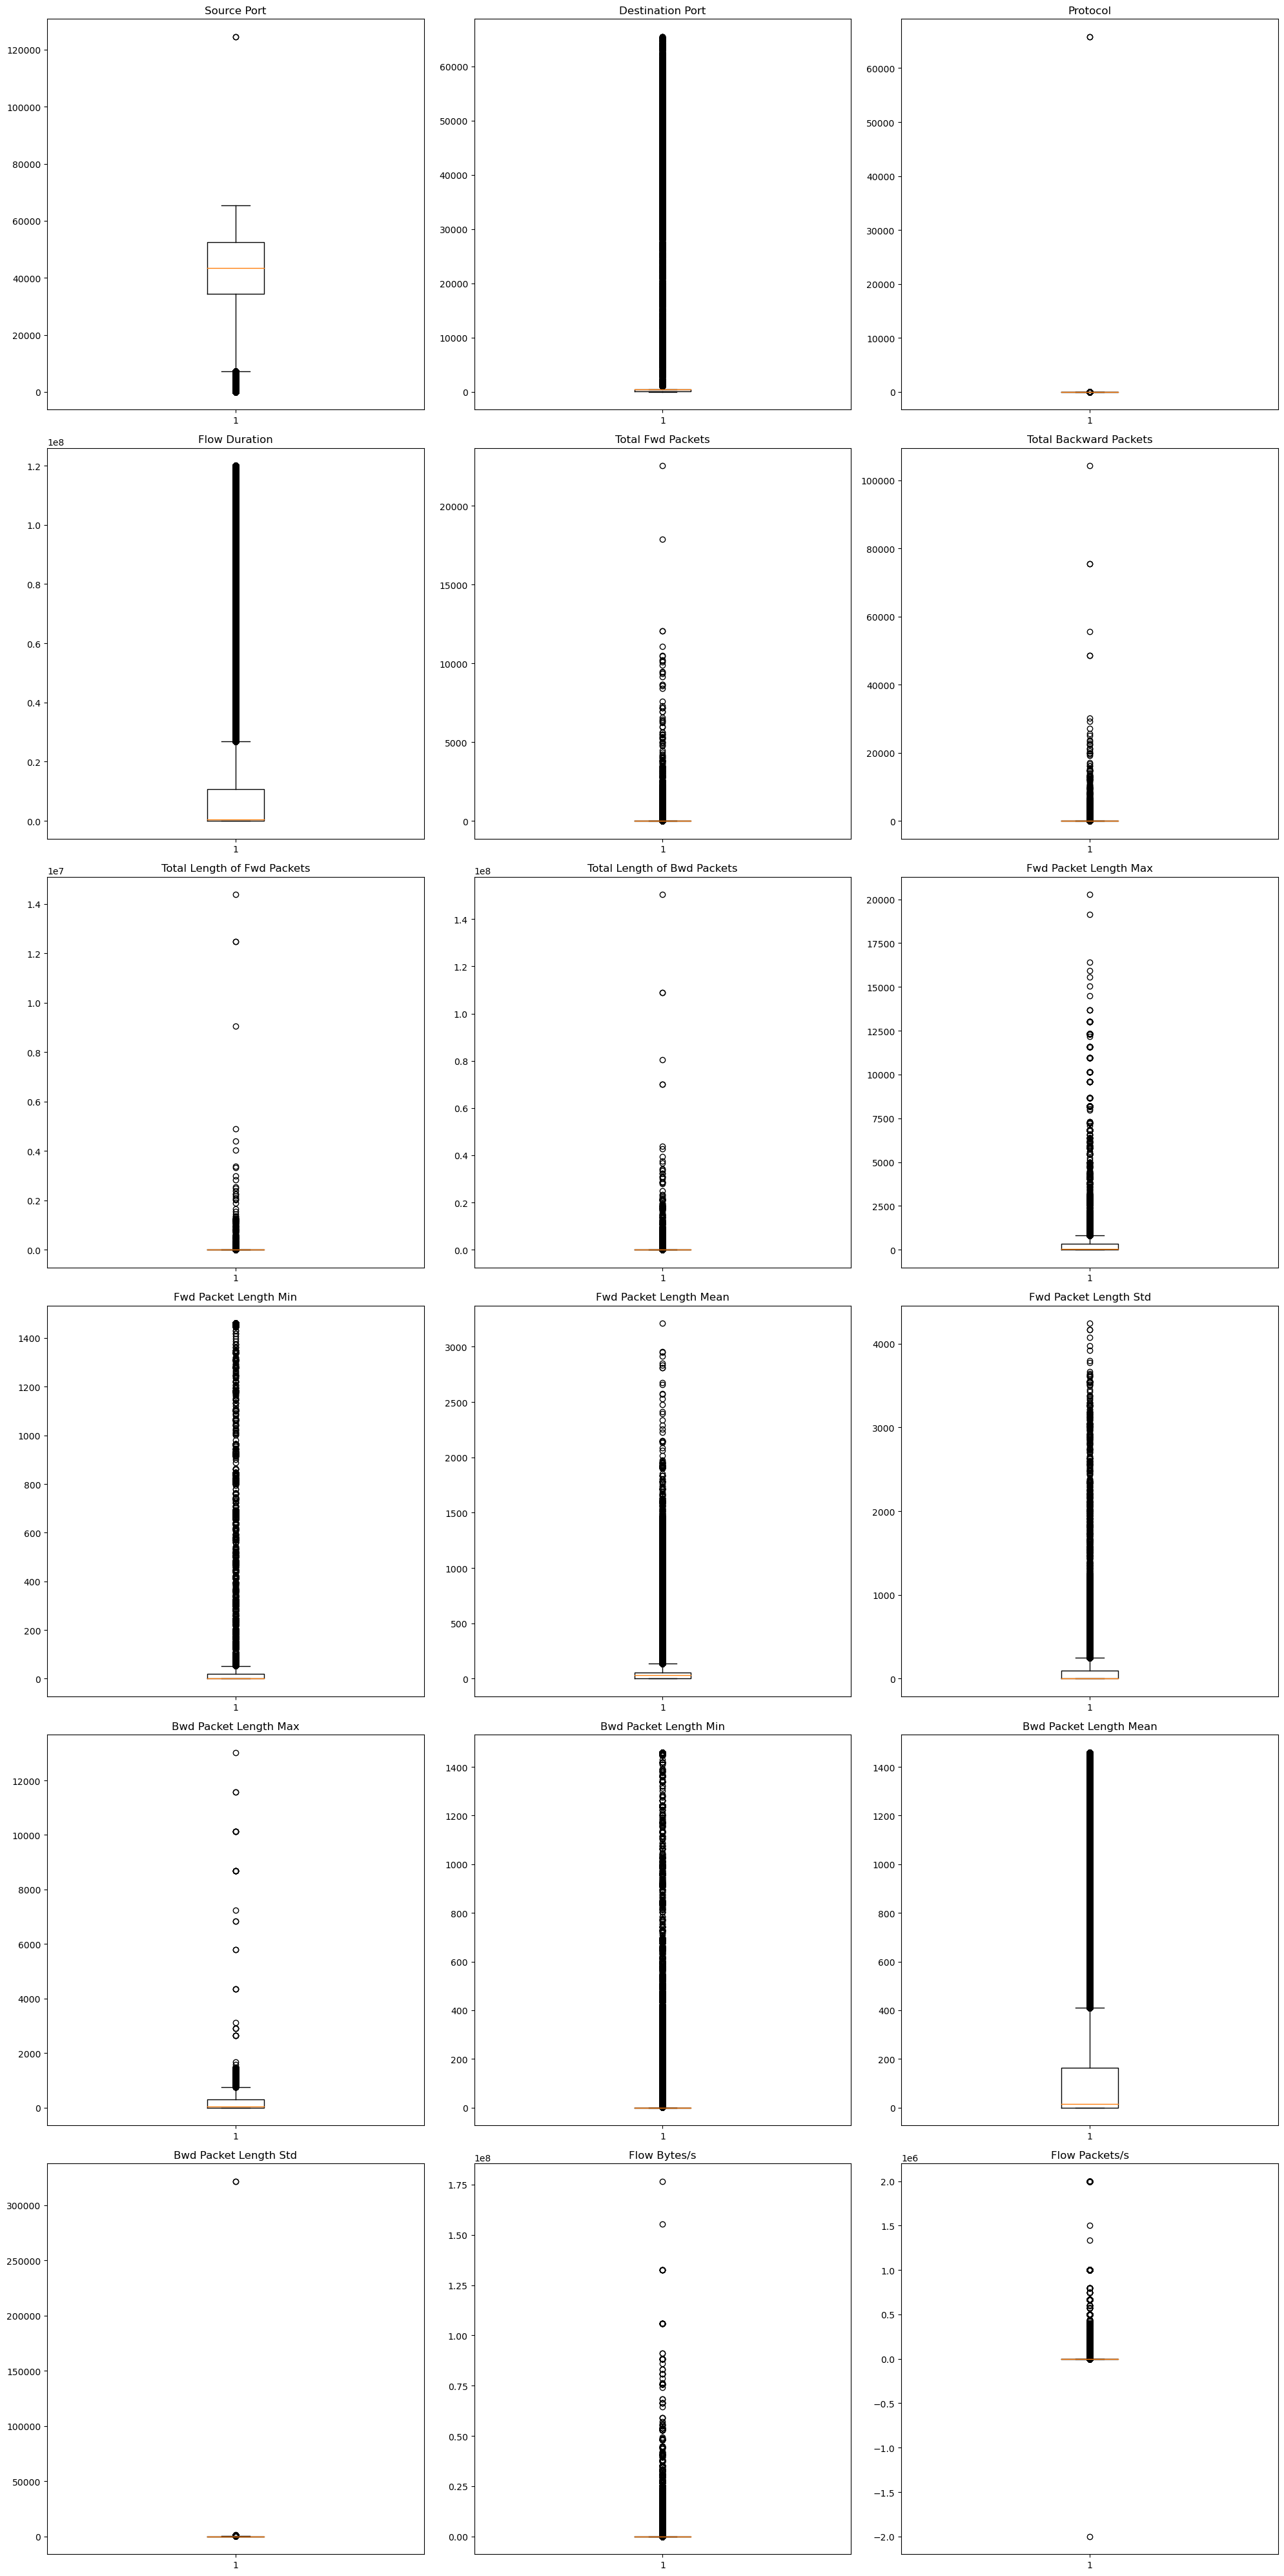

In [9]:
fig, ax = plt.subplots(6, 3, figsize = (20, 40))

i = 0
j = 0

columns = df_balanced.select_dtypes(include='number').columns

for col in columns:
    Q1 = np.percentile(df_balanced[col], 25)
    Q2 = np.percentile(df_balanced[col], 50)  # median
    Q3 = np.percentile(df_balanced[col], 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_iqr = (df_balanced[col] < lower_bound) | (df_balanced[col] > upper_bound) #outliers
    if df_balanced[col][mask_iqr].any() == True:
        ax[i, j].boxplot(df_balanced[col])
        ax[i, j].set_title(col)
        j += 1
        if j == 3:
            j = 0
            i +=1
            
plt.tight_layout()
plt.show()

Some observations
<span style="color:green">
    Flow duration appears to follow the same distribution for all mal and benign ware, although benign ware had a higher percent of shorter flow duration comapired ot the others. Flow latency also has a very similar distribution across all 5 wares and the swarm plot also confirms this. Although I used a chunked portion of the total dataset so that the code would run fast, it appears that a simple linear equation will not be enough to detemine if an application contains malware and model advanced models should be used. 
</span>

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!
<span style="color:green">
    The data is usable and points to the fact that a simple linear regression will not be enough to detect the type of malware a phone has. Some of the features had negative values which supprised me but after researching the topic more, I now know that negative values can be a sign that the connection was interupted, hence neative instead of the usual positive values. I kept the negatives because there was negatives in all 5 types of malware (including benign) and could be important. The data cleanng from week 2 and the transformations (log), helps with legability. 
</span>

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?
<span style="color:green">
    The numerical features were mostly right skewed with the exception of the flow of packets and header (forward, backward, total) length. Some packets had negative flows or lengths because the connection was interupted, but for the most part, almost all the features had a couple values that were very high which caused long tails to the right. 
</span>

- Are there any outliers present?  (Data points that are far from the others.)
<span style="color:green">
    Yes, from the box plots theres evidence that some features had very high outliers but these could be legitmate values for lomger/heavier network flows, so I kept themm. For the negative outliers, I kept them becuse they represent when the connection was nterupted and could be important as well. 
</span>

- If there are multiple related histograms, how does the distribution change across different groups?
<span style="color:green">
    In the 'Top 3 Desination ports by Category' plot, the order of the distribution of the top 3 ports used by each malware (and benign) is the same (443, then 80, and finally 53) indicating that the wares perfered these destination ports but the amount they perfered each port slightly varried. In the 'Flow Durations by Category' plot, the flows were broken up into 5 categories (super short, short, medium, long, super long), and the distribution of the flows for all malware looked the same where the flows were in the following order of popularity: super long, short, medium, long, and super short. Benign was the only ware that varried in the previously established pattern of flow speeds. For benign, the following flows appeared to be about the same: short, medium, and super long. Lastly in the 'Forward vs Backward Packet' plot, theres more packets going from the server to the Android rather than from the Android to the server, which makes sense because its usually the people requesting information. Overall, its clear that benign does not necessarly stand out from the malware so a deeper analysis is required. 
</span>

- What are the minimum and maximum values represented in each histogram?
<span style="color:green">
    The min/max is shown in the df_balanced.describe() print out. I have kept negative values because they represent disconnected network flows. 
</span>

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?
<span style="color:green">
    Typically changing the number of bins or the size of the width, helps reveal the distribution of the data and I had fun trying to determine the best settings, however I found that when plotting for multiple plots in the same subplot, it was best to just leave the settings in default. This is because any change I applied, would apply to all the plots because of the for loop. Luckly, I think pyplot did a good job on choosing defaults that still let me see the distribution of the features. For the feat features where the distribution is not clear and looks unimodal because there is only 1 bar in the histograph, next time I would plot those charts seprately. 
</span>

- Does the distribution appear normal, or does it have a different distribution?
<span style="color:green">
    The distributions are mostly log normal and I will most likely have to find the natural log before I use the data to off set the log. 
</span>

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

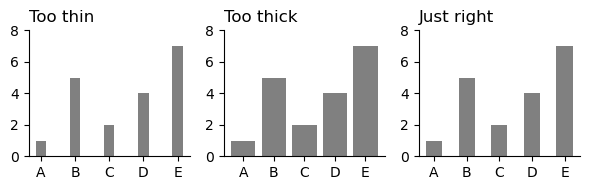

In [10]:
fig, ax = plt.subplots(1, 3, figsize = (6, 2))
data = {
    "group": ['A', 'B', 'C', 'D', 'E'],
    "value": [1, 5, 2, 4, 7]
}

ax[0].bar(data['group'], data['value'], width = .3, color = 'grey')
ax[0].set_title("Too thin", loc = "left")
ax[1].bar(data['group'], data['value'], width = .8, color = 'grey')
ax[1].set_title("Too thick", loc = "left")
ax[2].bar(data['group'], data['value'], width = .5, color = 'grey')
ax[2].set_title("Just right", loc = "left")


for axis in ax:
    axis.set_ylim(0, 8)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


fig.tight_layout()